# MULTIVARIATE - > FITUR NYA ADA BANYAK 

Sebelumnya fitur kita kan cuman 1 sekrang kita akan ekstrak date nya menjadi beberapa fitur yang mungkin dapat membuatnya lebih bermakna

In [263]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [264]:
import torch
from torch import nn, optim
# di sini kita akan masuk ke callback
from jcopdl.callback import Callback, set_config


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# Import Data

1. YANG PERLU KITA EDIT DI SINI ITU FITURNYA , SEKARANG KITA MAU MENAMBAHKAN FITUR KAYAK NYA INPUT BULAN NYA, KALAU TAHUN PATTERNYA(POLANYA) ITU SAMA KALAU DI BULAN . BULAN TERTENTU TEMPERATUR DI BUMI RENDAH DAN DI BULAN TERTENTU TEMPERATURNYA TINGGI . DI DATA KITA KAYAK NYA KITA BISA JADI INI PER KUARTAL DEH  

In [265]:
df = pd.read_csv(r"D:\Belajar ML dan AI\deep_learning-master\16 - Recurrent Neural Network\data\daily_min_temp.csv", parse_dates=["Date"])
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


2. Jadi Date nya kita jangan jadi in index karena date nya akan kita ekstrak/ di manfaatkan. kita akan ekstarak menjadi per quarter dan kita jadi kan fitur yang baru 

In [266]:
df["quarter"] = df.Date.dt.quarter
df.quarter
# jadi sekarang sudah di pisah kan per quarter 

0       1
1       1
2       1
3       1
4       1
       ..
3645    4
3646    4
3647    4
3648    4
3649    4
Name: quarter, Length: 3650, dtype: int32

In [267]:
# jadi sekarang fitur kita ada 2 maka sudah multivariete
df.head()

,Date,Temp,quarter
0,1981-01-01,20.7,1
1,1981-01-02,17.9,1
2,1981-01-03,18.8,1
3,1981-01-04,14.6,1
4,1981-01-05,15.8,1


3. quarter ini bisa numeric / categorik tapi lebih makesence categorik maka kita akan jadi kan kategorik dengan kita encode

In [268]:
df = pd.get_dummies(df, columns=["quarter"],dtype=float)
df.set_index("Date", inplace=True)# -> kita jadi index lagi DATE
df.head()

,Temp,quarter_1,quarter_2,quarter_3,quarter_4
Date,,,,,
1981-01-01,20.7,1.0,0.0,0.0,0.0
1981-01-02,17.9,1.0,0.0,0.0,0.0
1981-01-03,18.8,1.0,0.0,0.0,0.0
1981-01-04,14.6,1.0,0.0,0.0,0.0
1981-01-05,15.8,1.0,0.0,0.0,0.0


4. KITA AKAN COBA SCALING KARENA BISA MEMBANTU
perlu di perhatikan unutk code manual scaling dibawah ? perhatikan kita akan menghitung std dari semua,  bukanya itu datalekage ? benar maka nya kita harus hati - hati lebih baik pakai (sklearn aja) . tapi unutk case data kita ini boleh karena kita bisa lihat di plotan data kita hampir std nya tidak ada perubahan 



In [ ]:
# df.Temp = df.Temp.transform(lambda x: (x - x.mean()/ x.std()))

<Axes: xlabel='Date'>

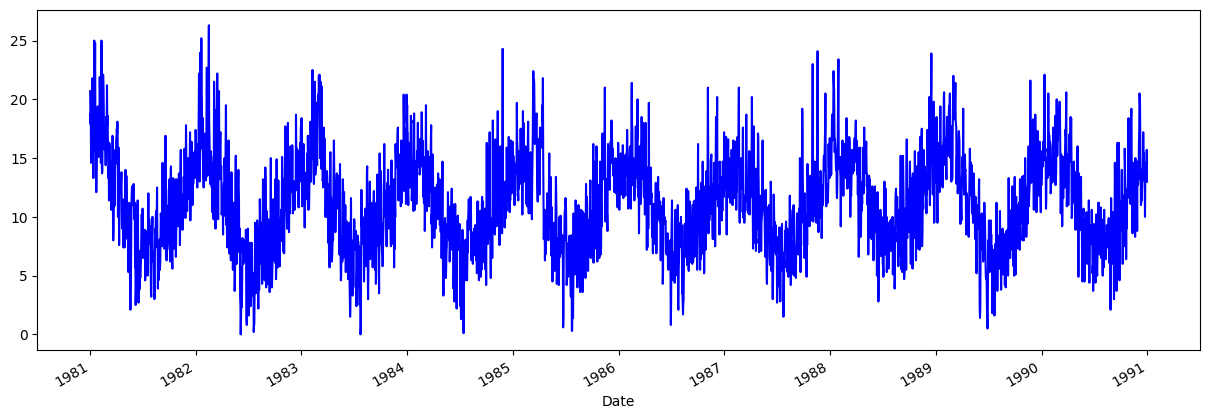

In [269]:
df.Temp.plot(figsize=(15,5), color="b")

In [270]:
df.head()

,Temp,quarter_1,quarter_2,quarter_3,quarter_4
Date,,,,,
1981-01-01,20.7,1.0,0.0,0.0,0.0
1981-01-02,17.9,1.0,0.0,0.0,0.0
1981-01-03,18.8,1.0,0.0,0.0,0.0
1981-01-04,14.6,1.0,0.0,0.0,0.0
1981-01-05,15.8,1.0,0.0,0.0,0.0


In [271]:
df

,Temp,quarter_1,quarter_2,quarter_3,quarter_4
Date,,,,,
1981-01-01,20.7,1.0,0.0,0.0,0.0
1981-01-02,17.9,1.0,0.0,0.0,0.0
1981-01-03,18.8,1.0,0.0,0.0,0.0
1981-01-04,14.6,1.0,0.0,0.0,0.0
1981-01-05,15.8,1.0,0.0,0.0,0.0
...,...,...,...,...,...
1990-12-27,14.0,0.0,0.0,0.0,1.0
1990-12-28,13.6,0.0,0.0,0.0,1.0
1990-12-29,13.5,0.0,0.0,0.0,1.0


In [272]:
df.values

array([[20.7,  1. ,  0. ,  0. ,  0. ],
       [17.9,  1. ,  0. ,  0. ,  0. ],
       [18.8,  1. ,  0. ,  0. ,  0. ],
       ...,
       [13.5,  0. ,  0. ,  0. ,  1. ],
       [15.7,  0. ,  0. ,  0. ,  1. ],
       [13. ,  0. ,  0. ,  0. ,  1. ]], shape=(3650, 5))

# Daset Spliting

In [273]:
ts_train, ts_test = train_test_split(df, test_size=0.2,shuffle=False,)
ts_train.shape, ts_test.shape

((2920, 5), (730, 5))

# Daset dan Dataloader

In [274]:
from torch.utils.data import  DataLoader
from jcopdl.utils.dataloader import TimeSeriesDataset

1. Yang ini Versi coustom datasetnya

In [275]:
import torch
from torch.utils.data import Dataset  # Pastikan baris ini ada

class MyTimeSeriesDataset(Dataset):
    def __init__(self, data, target_cols, seq_len):
        self.columns = data.columns.tolist()
        
        # --- Tambahkan ini ---
        # Mengambil indeks dari DataFrame (misal: tanggal/waktu) 
        # mulai dari data ke-seq_len hingga akhir
        self.target_ticks = data.index[seq_len:]
        # ---------------------
        
        if isinstance(target_cols, str):
            target_cols = [target_cols]
            
        for col in target_cols:
            if col not in self.columns:
                raise ValueError(f"Kolom '{col}' tidak ditemukan.")
        
        self.target_indices = [self.columns.index(col) for col in target_cols]
        self.data = torch.tensor(data.values, dtype=torch.float32)
        self.seq_len = seq_len
        self.num_targets = len(target_cols)

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len, self.target_indices]
        return x, y.view(-1) 

    def __repr__(self):
        return f"TimeSeriesDataset(Total Data={len(self.data)}, SeqLen={self.seq_len}, TargetCols={self.num_targets})"

In [276]:
seq_len = 14
bs = 32

# unut kolom targetnya lebih dari 1 harus dalam list
# di sini kita kolom targetnya hanya 1 
train_set = MyTimeSeriesDataset(ts_train,"Temp", seq_len)
trainloader = DataLoader(train_set, batch_size=bs, shuffle=True,)

test_set = MyTimeSeriesDataset(ts_test,"Temp",seq_len)
testloader = DataLoader(test_set, batch_size=bs, shuffle=False)

# Arsitektur dan config

In [277]:
from jcopdl.layers import linear_block

In [278]:
class GRU(nn.Module):
    def __init__(self, input_size, output_size, hidden_size, num_layers, dropout,  ):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

        
    def forward(self, x, hidden):
        x, hidden = self.rnn(x, hidden)
        x = self.fc(x[:, -1, :])   # hanya timestep terakhir → [batch, output_size]
        return x, hidden

Jadi Bedanya adalah :
1. Ganti nama fungsi nya dengan LSTM
2. Pytorch sudah menyediakan LSTM block nya 

In [279]:
# di sini 
train_set.data.shape[1] 

5

In [280]:
from types import SimpleNamespace

def set_config(params):
    return SimpleNamespace(**params)

# Penggunaan:
config = set_config({
    "input_size": train_set.data.shape[1],
    "output_size": train_set.num_targets,
    "hidden_size": 128,        # Ditingkatkan untuk kapasitas memori model
    "num_layers": 2,           # Menjaga kedalaman agar tidak terlalu kompleks
    "dropout": 0.2,
         # Regularisasi untuk mencegah overfitting
    "seq_len": train_set.seq_len
})

# MCOC

In [281]:
model = GRU(config.input_size, config.output_size,config.hidden_size,config.num_layers, config.dropout).to(device)
criterion = nn.MSELoss(reduction="mean")
optimizer = optim.AdamW(model.parameters(), lr=0.0005)
callback = Callback(model, config, outdir="model/LSTM")

# Training

In [282]:
from tqdm.auto import tqdm

def loop_fn(mode, dataset, dataloader, model, criterion, optimizer, device):
    if mode == "train":
        model.train()
    elif mode == "test":
        model.eval()
    cost = 0
    for feature, target in tqdm(dataloader, desc=mode.title()):
        feature, target = feature.to(device), target.to(device)
        # BEDANYA CUMAN DI SINI DOANG NN DENGAM RNN
        output, hidden = model(feature, None)
        loss = criterion(output, target)
        
        if mode == "train":
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        
        cost += loss.item() * feature.shape[0]
    cost = cost / len(dataset)
    return cost

Train:   0%|          | 0/91 [00:00<?, ?it/s]

Test:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch     1
Train_cost  = 42.8630 | Test_cost  = 20.0309 | 


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Test:   0%|          | 0/23 [00:00<?, ?it/s]

...

Test:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch    19
Train_cost  = 5.9193 | Test_cost  = 4.7402 | 
==> EarlyStop patience =  2 | Best test_cost: 4.7129


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Test:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch    20
Train_cost  = 5.9576 | Test_cost  = 4.6439 | 


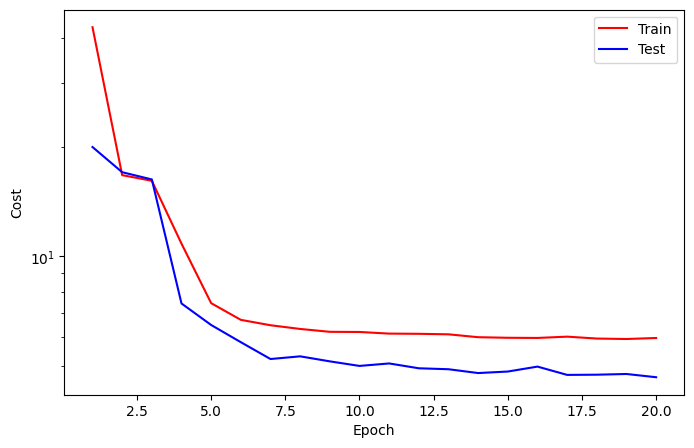

Train:   0%|          | 0/91 [00:00<?, ?it/s]

Test:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch    21
Train_cost  = 5.9413 | Test_cost  = 4.6245 | 


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Test:   0%|          | 0/23 [00:00<?, ?it/s]

...


Epoch    29
Train_cost  = 5.7692 | Test_cost  = 5.1277 | 
==> EarlyStop patience =  4 | Best test_cost: 4.5504


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Test:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch    30
Train_cost  = 5.8419 | Test_cost  = 4.5616 | 
==> EarlyStop patience =  5 | Best test_cost: 4.5504
==> Execute Early Stopping at epoch: 30 | Best test_cost: 4.5504
==> Best model is saved at model/LSTM


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\jcopdl\callback\_callback.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(

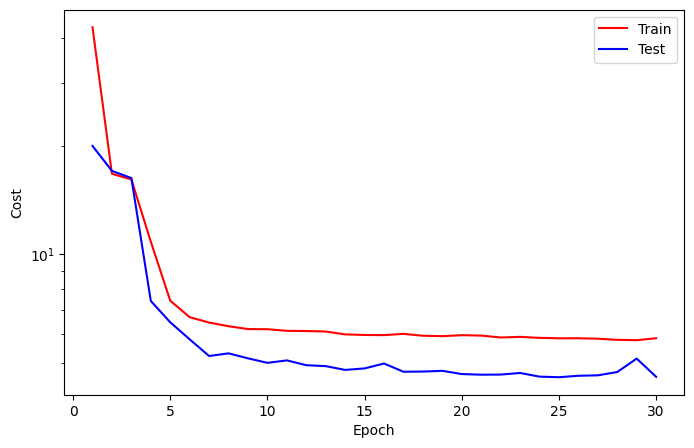

In [283]:
while True:
    train_cost = loop_fn("train", train_set, trainloader, model, criterion, optimizer, device)
    with torch.no_grad():
        test_cost = loop_fn("test", test_set, testloader, model, criterion, optimizer, device)
    
    # Logging
    callback.log(train_cost, test_cost)

    # Checkpoint
    callback.save_checkpoint()
        
    # Runtime Plotting
    callback.cost_runtime_plotting()
    
    # Early Stopping
    if callback.early_stopping(model, monitor="test_cost"):
        callback.plot_cost()
        break


# FORCESTING


In [284]:
from utils import data4pred, pred4pred

In [285]:
train_forcest = TimeSeriesDataset(ts_train,"Temp", 1)
trainforcestloader = DataLoader(train_forcest)

test_forcest = TimeSeriesDataset(ts_test,"Temp",1)
testdorcestloader = DataLoader(test_forcest)


(N, S, F): (2919, 1, 5)
Note: last 0 data excluded

(N, S, F): (729, 1, 5)
Note: last 0 data excluded



Text(0.5, 1.0, 'Test')

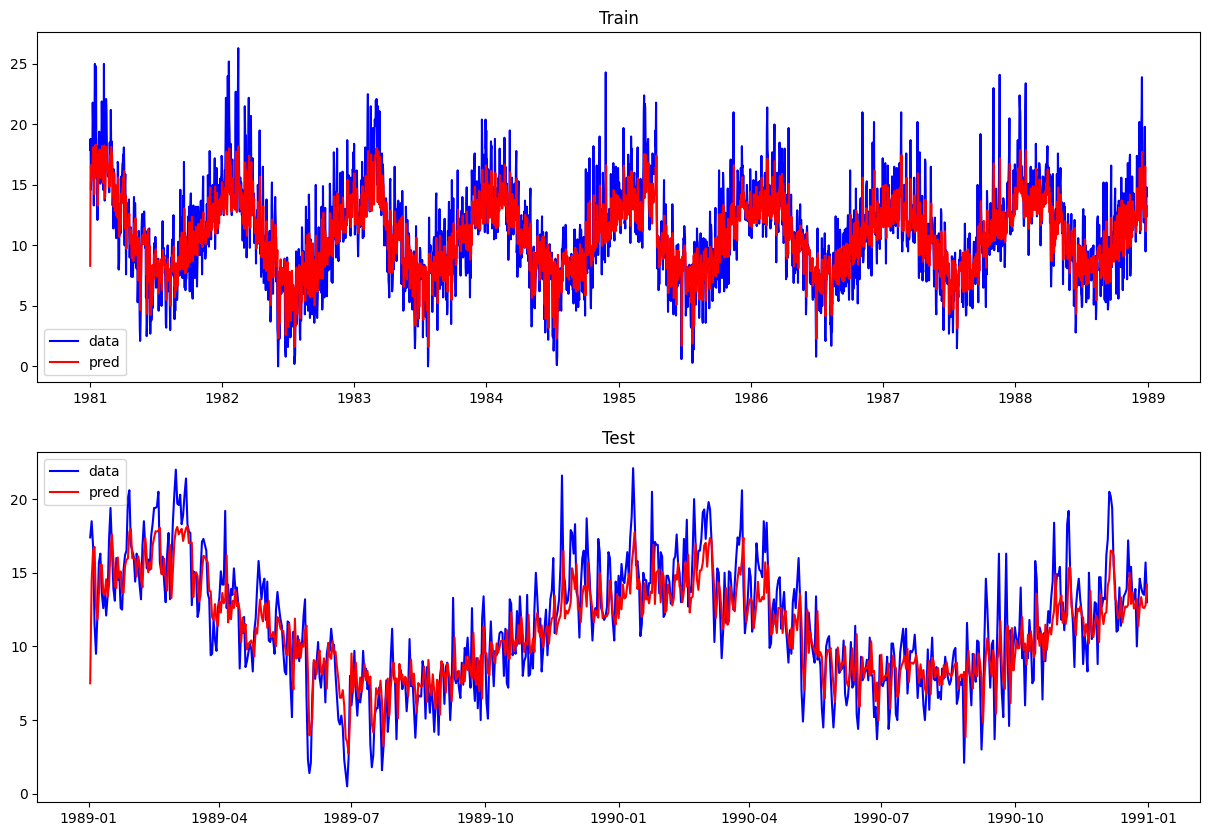

In [286]:
plt.figure(figsize=(15, 10))

plt.subplot(211)
data4pred(model, train_forcest, trainforcestloader, device)
plt.title("Train")

plt.subplot(212)
data4pred(model,test_forcest, testdorcestloader, device)
plt.title("Test")

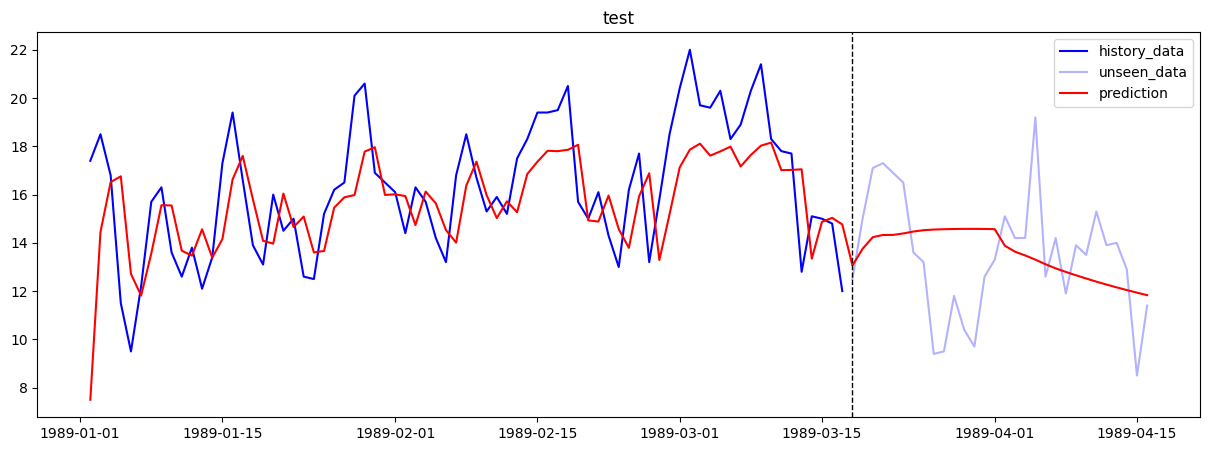

In [287]:
plt.figure(figsize=(15, 5))
pred4pred(model, test_forcest, testdorcestloader , device)
plt.title("test");


Jadi Kesimpulannya sudah bener sequns_leng nya di uabh ke 16 itu bekerja , karena informasinya cukup jadi sebenarnya ml itu dia hanya mencari pola , tugas kita adalah seberapa banyak informasi yang masuk akal yang fitur nya bermakna supya machine lebih bagus

# Coba yang menarik kita akan forcest unutk memprediksi semuanya 

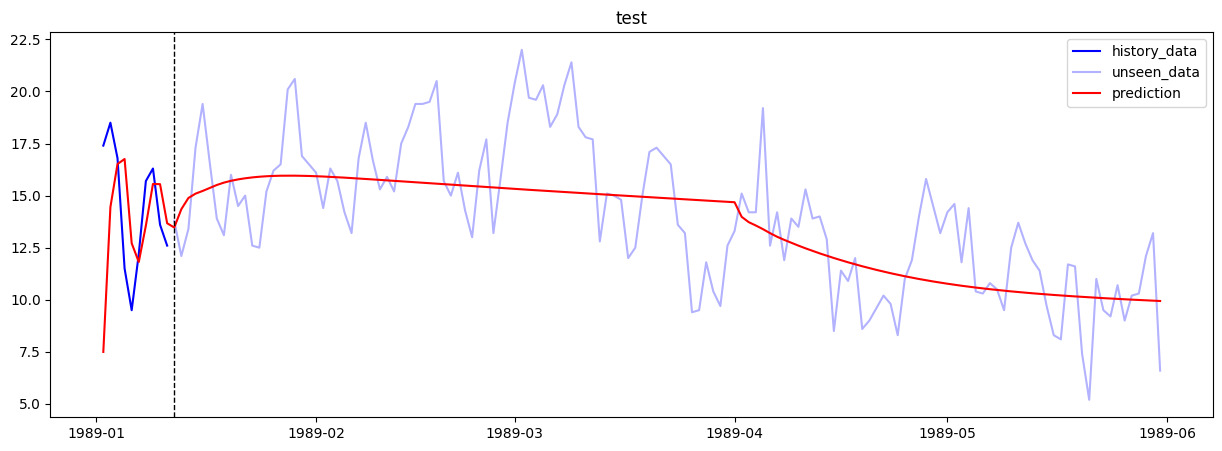

In [288]:
# n_prior kita akan mengambil konteks 10 data di awal 
# n_forcest model akan mencoba memprediksi 140 langkah waktu ke depan setelah titik akhir dari n_prior
plt.figure(figsize=(15, 5))
pred4pred(model, test_forcest, testdorcestloader , device, n_prior=10, n_forecast=140)
plt.title("test");


Nah walaupun kita sudah kasih rnn sequend_leng nya sudah makesence pun semakin jauh prediksi kita di masa depan itu semakin meleset, jg merasa bersalah prediksi nya meleset karena prediksi semakin jauh ke masa depan itu semakin tinggi ketidak pastian nya 

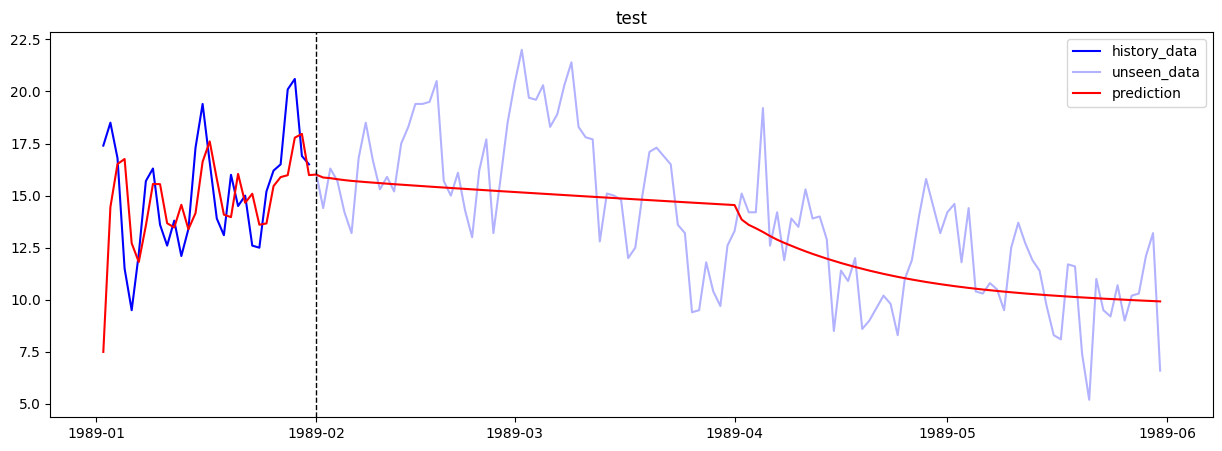

In [289]:
# mungkin konteks kita di atas kurang kalau cuman 10 
# maka unutk konteks nya akan kita naikan ke 30
plt.figure(figsize=(15, 5))
pred4pred(model, test_forcest, testdorcestloader , device, n_prior=30, n_forecast=120)
plt.title("test");

Hal yang menarik di time series forcesting bydefault itu oferfit kita harus harap prediksi kita salah jadi jangan khawatir kalau salah , kalau kita bisa jamin prediksi akurat maka gak akan ada masalah lagi di dunia ini